In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/defect_detector/data.zip" -d /content/

In [ ]:
!pip install -q torch torchvision scikit-learn pandas pillow

In [ ]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset


In [ ]:
from pathlib import Path

In [ ]:
!git clone https://github.com/Phuc1Le/defect_detector.git

Cloning into 'defect_detector'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 87 (delta 52), reused 62 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 1.31 MiB | 17.86 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [ ]:
%cd /content/defect_detector/

/content/defect_detector


In [ ]:
!git pull

Already up to date.


In [ ]:
import pandas as pd, torch

In [ ]:
import sys
sys.path.append("/content/defect_detector/src")

In [ ]:
from train import train_model, TRANSFORM
from evaluate import report

In [ ]:
%cd ..

/content


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
manifest = pd.read_csv("manifest.csv")
synthetic = pd.read_csv("synthetic_manifest.csv")   # from Week 1 — ALL of Week 2 training data
test_df = manifest[manifest.split == "test"]        # NEVER used above this line
print(synthetic.iloc[0].filepath)
model = train_model(synthetic, device)
metrics = report(model, test_df, device, TRANSFORM)
print("Bootstrap (0 real labels) metrics:", metrics)

torch.save(model.state_dict(), "bootstrap_model.pt")

data\raw\bottle\test\good\002.png
Training label counts:
label
0     73
1    219
Name: count, dtype: int64
DataLoader sampled counts: {0: 151, 1: 141}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


  epoch 1/8  loss=0.7133
  epoch 2/8  loss=0.6858
  epoch 3/8  loss=0.6983
  epoch 4/8  loss=0.6915
  epoch 5/8  loss=0.6848
  epoch 6/8  loss=0.6996
  epoch 7/8  loss=0.6910
  epoch 8/8  loss=0.6709
Probabilities: min=0.255, max=0.907, mean=0.489
Bootstrap (0 real labels) metrics: {'accuracy': 0.7288135593220338, 'precision': 0.42857142857142855, 'recall': 0.6923076923076923, 'f1': 0.5294117647058824}


In [ ]:
from experiment import experiment

In [ ]:
from pathlib import Path
from PIL import Image

p = Path("data/raw/bottle/train/good/110.png")

print("cwd:", Path.cwd())
print("exists:", p.exists())
print("absolute:", p.resolve())

img = Image.open(p)
print("Opened successfully!")

cwd: /content
exists: True
absolute: /content/data/raw/bottle/train/good/110.png
Opened successfully!


In [ ]:
pwd

'/content'


===== Seed 0 =====
label
1    219
0     73
Name: count, dtype: int64
0.8235563039779663
  epoch 1/4  loss=0.7562
  epoch 2/4  loss=0.7193
  epoch 3/4  loss=0.7400
  epoch 4/4  loss=0.7259
Probabilities: min=0.267, max=0.632, mean=0.437
[active] round 0: labels_used=0 acc=0.780
label
1    226
0     86
Name: count, dtype: int64
0.8190652132034302
  epoch 1/4  loss=0.6980
  epoch 2/4  loss=0.6880
  epoch 3/4  loss=0.6903
  epoch 4/4  loss=0.6713
Probabilities: min=0.202, max=0.696, mean=0.441
[active] round 1: labels_used=20 acc=0.797
label
1    234
0     98
Name: count, dtype: int64
0.8195158839225769
  epoch 1/4  loss=0.6685
  epoch 2/4  loss=0.6556
  epoch 3/4  loss=0.6468
  epoch 4/4  loss=0.6511
Probabilities: min=0.229, max=0.828, mean=0.482
[active] round 2: labels_used=40 acc=0.831
label
1    242
0    110
Name: count, dtype: int64
0.8230257034301758
  epoch 1/4  loss=0.6479
  epoch 2/4  loss=0.6560
  epoch 3/4  loss=0.6408
  epoch 4/4  loss=0.6356
Probabilities: min=0.319, max=0.

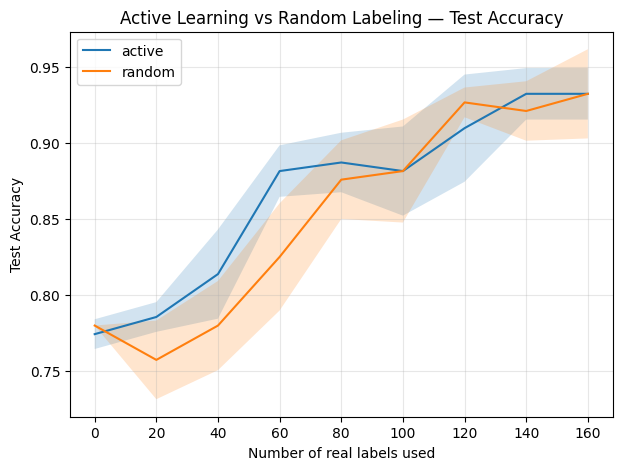

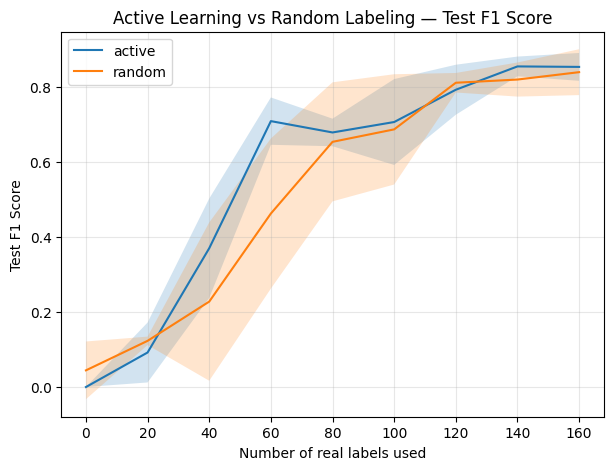


Average metrics across seeds:
   strategy  labels_used  accuracy_mean  accuracy_std  precision_mean  \
0    active            0          0.774         0.010           0.000   
1    active           20          0.785         0.010           0.500   
2    active           40          0.814         0.029           0.738   
3    active           60          0.881         0.017           0.770   
4    active           80          0.887         0.020           0.926   
5    active          100          0.881         0.029           0.766   
6    active          120          0.910         0.035           0.835   
7    active          140          0.932         0.017           0.822   
8    active          160          0.932         0.017           0.814   
9    random            0          0.780         0.000           0.167   
10   random           20          0.757         0.026           0.344   
11   random           40          0.780         0.029           0.485   
12   random         

In [ ]:
experiment()